Importing the Dependencies

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn import metrics
from sklearn.linear_model import LogisticRegression

Data Collection & Pre-Processing

In [5]:
mail_data = pd.read_csv('/content/mail_data.csv')

In [6]:
# number of rows and columns
mail_data.shape

(5572, 2)

In [8]:
# showing the first 5 rows of data
mail_data.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


<Axes: xlabel='Category', ylabel='count'>

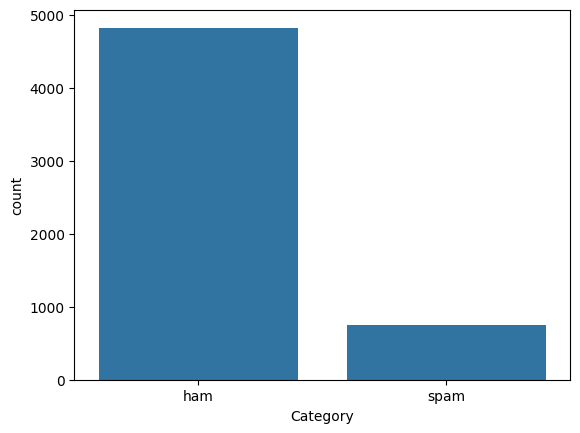

In [9]:
# checking the distribution
sns.countplot(data=mail_data,x='Category')

In [10]:
mail_data.Category.value_counts(normalize=True)*100

,proportion
Category,
ham,86.593683
spam,13.406317


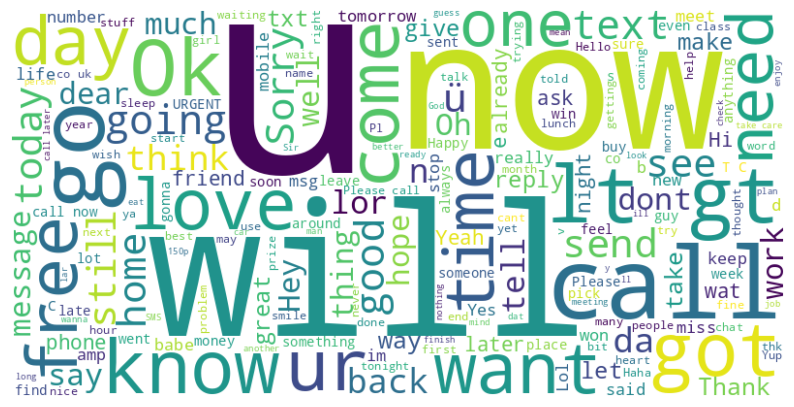

In [14]:
from wordcloud import WordCloud, STOPWORDS

wcloud = WordCloud(width=800, height=400, background_color='white', stopwords=STOPWORDS).generate(mail_data.Message.str.cat(sep=' '))

plt.figure(figsize=(10,10))
plt.imshow(wcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


In [31]:
tfidf = TfidfVectorizer(max_features=5000, min_df=2, max_df=.9, sublinear_tf=True, ngram_range=(1,3), stop_words='english')
text_v = tfidf.fit_transform(mail_data.Message)

In [32]:
features = pd.DataFrame(text_v.toarray(), columns=tfidf.get_feature_names_out())

In [33]:
label = mail_data.Category

In [34]:
label.value_counts()

,count
Category,
ham,4825
spam,747


In [35]:
label = label.replace({'ham':0, 'spam':1})

/tmp/ipykernel_21329/1942168700.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  label = label.replace({'ham':0, 'spam':1})


Splitting the data into training data and test data

In [36]:
X_train, X_test, y_train, y_test = train_test_split(features, label, test_size=.2, random_state=1)

In [37]:
log = LogisticRegression(max_iter=100)
log.fit(X_train, y_train)

LogisticRegression()

In [38]:
metrics.accuracy_score(y_test, log.predict(X_test))

0.9695067264573991

In [39]:
metrics.precision_score(y_test, log.predict(X_test))

0.9829059829059829

In [40]:
metrics.recall_score(y_test, log.predict(X_test))

0.782312925170068

The Logistic Regression model only missed actual spams like 22% of the time.
And of all the predictions, 97% of the time it correctly predicted actual spams and hams

Building a Predictive System

In [42]:
input_mail=["I'm back &amp; we're packing the car now, I'll let you know if there's room"]

# convert the text to feature vectors
input_data_features = tfidf.transform(input_mail)

# making prediction

prediction = log.predict(input_data_features)
if prediction==0:
  print('Not a spam')
else:
  print('Spam')

Not a spam
